# Day 5: Data Visualization: Matplotlib & Seaborn

## Some Questions

### 1. When would you use a bar chart vs a histogram?

    Bar Chart: Used for comparing discrete categorical data groups (e.g., comparing total sales across different gaming platforms like PS4, Xbox, Wii). The bars have gaps between them so they're different than histograms in that regard.

    Histogram: Used for exploring the distribution of a single continuous numerical variable (e.g., looking at how game release counts drop or spike across different calendar years). The continuous range is broken into sequential intervals called "bins," and the bars touch.

### 2. What is the difference between `plt.plot()` and `sns.lineplot()`?

    `plt.plot()` (Matplotlib): A low-level function that plots raw data coordinates exactly as they are supplied. It does not automatically handle dataset grouping, averaging etc

    `sns.lineplot()` (Seaborn): A higher-level, dataset-aware function. If a single X-axis variable has multiple data observations, Seaborn automatically aggregates them (computing the mean) and draws a shaded error band representing the confidence interval out of the box.

### 3. What does a boxplot actually show, what are the whiskers?

    A boxplot visualizes the five-number summary of a distribution:

    1. Median (Q2 / 50th percentile): The line cutting through the main box.

    2. Lower Quartile (Q1 / 25th percentile): The bottom edge of the main box.

    3. Upper Quartile (Q3 / 75th percentile): The top edge of the main box.

    4. Whiskers: Extend from the edges of the box to show the range of reasonable data variability. They typically extend to 1.5 × IQR (Interquartile Range) past the quartiles.
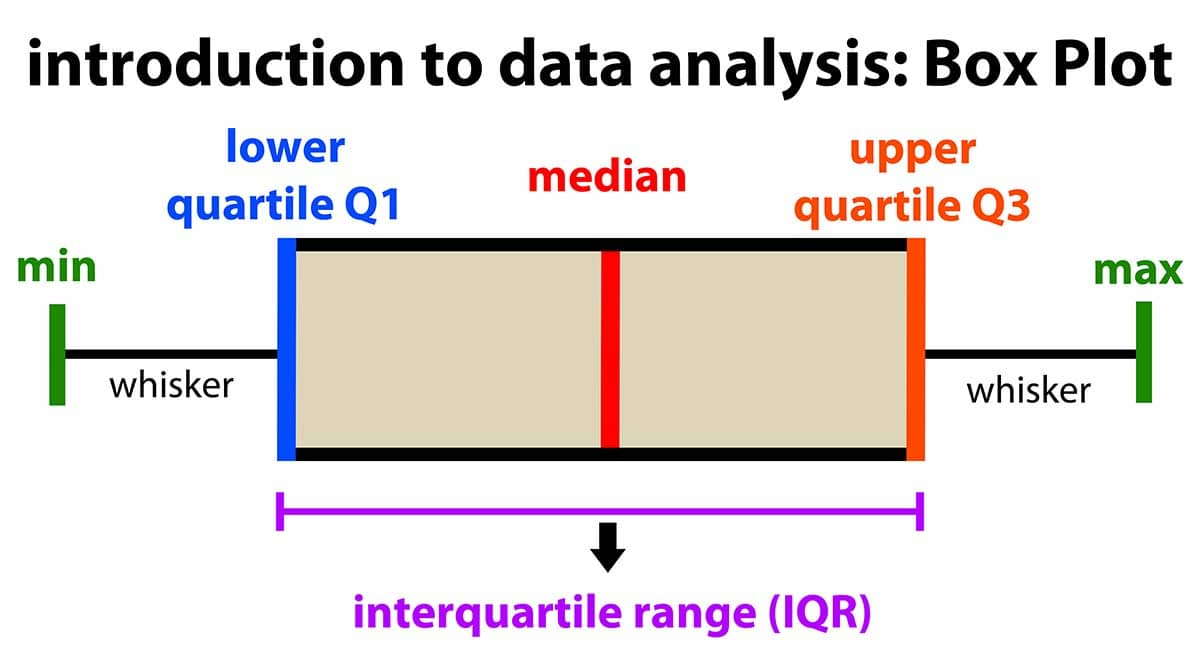
    5. Outliers: Any data points plotted as individual dots lying completely outside the whiskers.

### 4. How do you plot multiple charts in one figure using Matplotlib?

we use use the `plt.subplots()` framework to establish a grid layout by passing the required row and column parameters:

```python
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(12, 10))
sns.histplot(data=df, x='Global_Sales', ax=axes[0, 0])  
```
### 5. What is a heatmap useful for and what kind of data does it work best with?

a heatmap visualizes cross-sectional intensity values using a color palette. It works best with rectangular numeric correlation matrices or pivot tables where you want to quickly identify patterns, correlations, or anomalies across multiple variables.


## Moving onto the Task

In [81]:
import warnings
warnings.filterwarnings('ignore')

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# day 3 and 4 params
df = pd.read_csv('vgsales.csv')
df['Publisher'] = df['Publisher'].fillna('Unknown')
df = df.dropna(subset=['Year'])
df['Year'] = df['Year'].astype(int)
df = df.drop_duplicates()

df

,Rank,Name,Platform,Year,Genre,Publisher,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
0,1,Wii Sports,Wii,2006,Sports,Nintendo,41.49,29.02,3.77,8.46,82.74
1,2,Super Mario Bros.,NES,1985,Platform,Nintendo,29.08,3.58,6.81,0.77,40.24
2,3,Mario Kart Wii,Wii,2008,Racing,Nintendo,15.85,12.88,3.79,3.31,35.82
3,4,Wii Sports Resort,Wii,2009,Sports,Nintendo,15.75,11.01,3.28,2.96,33.00
4,5,Pokemon Red/Pokemon Blue,GB,1996,Role-Playing,Nintendo,11.27,8.89,10.22,1.00,31.37
...,...,...,...,...,...,...,...,...,...,...,...
16593,16596,Woody Woodpecker in Crazy Castle 5,GBA,2002,Platform,Kemco,0.01,0.00,0.00,0.00,0.01
16594,16597,Men in Black II: Alien Escape,GC,2003,Shooter,Infogrames,0.01,0.00,0.00,0.00,0.01
16595,16598,SCORE International Baja 1000: The Official Game,PS2,2008,Racing,Activision,0.00,0.00,0.00,0.00,0.01
16596,16599,Know How 2,DS,2010,Puzzle,7G//AMES,0.00,0.01,0.00,0.00,0.01


In [48]:
df.describe()

,Rank,Year,NA_Sales,EU_Sales,JP_Sales,Other_Sales,Global_Sales
count,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000,16327.000000
mean,8292.868194,2006.406443,0.265415,0.147554,0.078661,0.048325,0.540232
std,4792.669778,5.828981,0.821591,0.508766,0.311557,0.189885,1.565732
min,1.000000,1980.000000,0.000000,0.000000,0.000000,0.000000,0.010000
25%,4136.500000,2003.000000,0.000000,0.000000,0.000000,0.000000,0.060000
50%,8295.000000,2007.000000,0.080000,0.020000,0.000000,0.010000,0.170000
75%,12441.500000,2010.000000,0.240000,0.110000,0.040000,0.040000,0.480000
max,16600.000000,2020.000000,41.490000,29.020000,10.220000,10.570000,82.740000


In [49]:
df.isna().sum()

Rank            0
Name            0
Platform        0
Year            0
Genre           0
Publisher       0
NA_Sales        0
EU_Sales        0
JP_Sales        0
Other_Sales     0
Global_Sales    0
dtype: int64

In [50]:
df.Year

0        2006
1        1985
2        2008
3        2009
4        1996
         ... 
16593    2002
16594    2003
16595    2008
16596    2010
16597    2003
Name: Year, Length: 16327, dtype: int64

### 1. Histogram of Game Releases Across Years

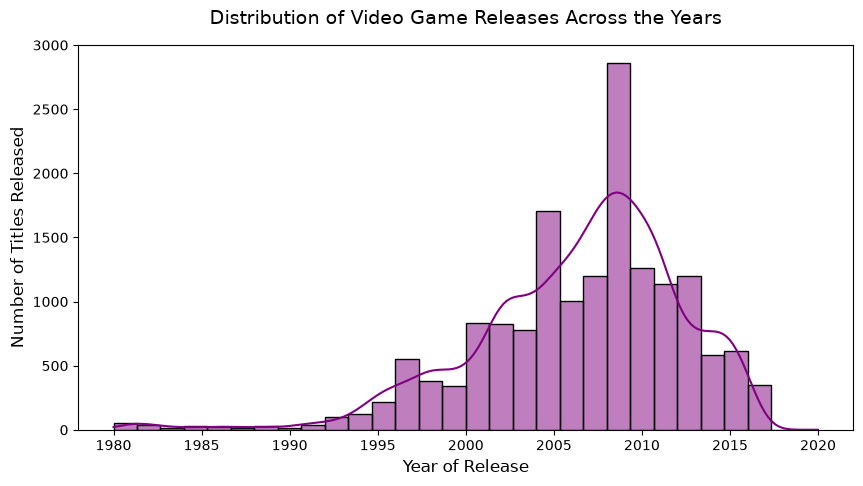

In [70]:
plt.figure(figsize=(10, 5))
sns.histplot(data=df, x='Year', bins=30, kde=True, color='purple')
plt.title('Distribution of Video Game Releases Across the Years', fontsize=14, pad=15)
plt.xlabel('Year of Release', fontsize=12)
plt.ylabel('Number of Titles Released', fontsize=12)
plt.show()

**Interpretation:** This histogram shows the distribution of game releases over time. We can clearly observe that video game releases began scaling rapidly during the late 1990s, peaking dramatically around *2008–2009*. Then, there is a visible decline in total entries, which aligns with the industry's shift toward digital distribution platforms and mobile gaming ecosystems!


### 2: Bar Chart of Average Global Sales by Genre

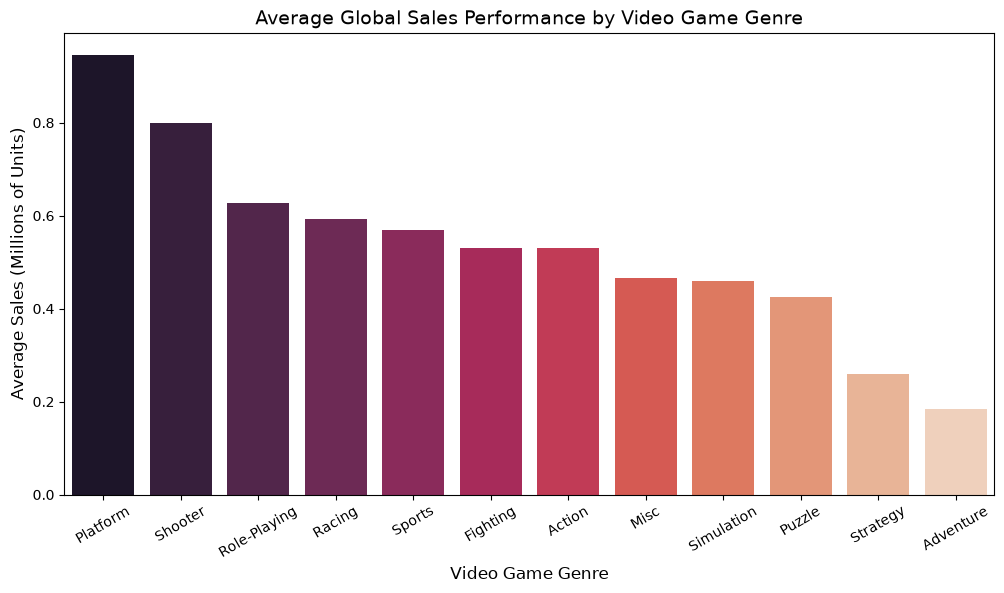

In [76]:
plt.figure(figsize=(12, 6))
# calcing mean global sales in descending
genre_order = df.groupby('Genre')['Global_Sales'].mean().sort_values(ascending=False).index

sns.barplot(data=df, x='Genre', y='Global_Sales', order=genre_order, palette='rocket', errorbar=None)     #errorbars were turned off
plt.title('Average Global Sales Performance by Video Game Genre', fontsize=14)
plt.xlabel('Video Game Genre', fontsize=12)
plt.ylabel('Average Sales (Millions of Units)', fontsize=12)
plt.xticks(rotation=30)
plt.show()

**Interpretation:** This bar chart shows the average sales for each game genre. While Action games had the highest total sales overall, this chart shows that Platform, Shooter, and Role-Playing games have the highest average sales per game. This suggests that these genres have more big-selling titles, while genres like Adventure release many games but usually have lower sales per title.

### 3: Boxplot of Regional Sales Distribution

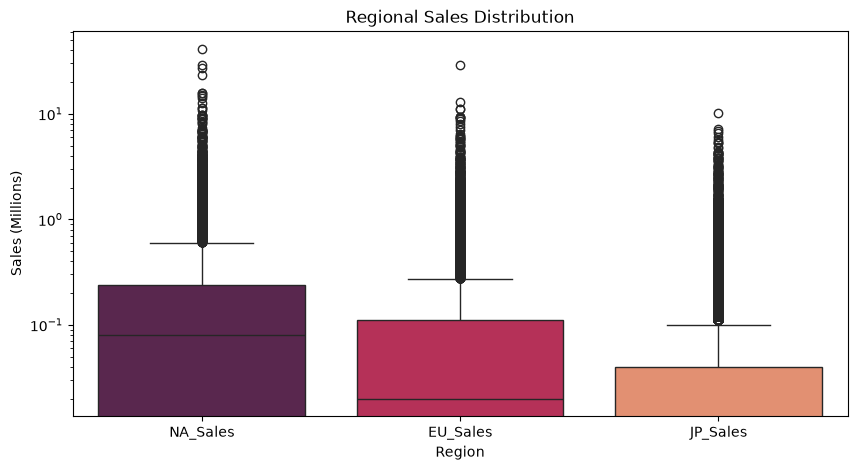

In [72]:
plt.figure(figsize=(10, 5))

sns.boxplot(data=df[['NA_Sales', 'EU_Sales', 'JP_Sales']], palette = "rocket")

plt.yscale('log')    #had to go for log since there are a lotta games that were sold, we dont want a sqaushed boxplot
plt.title('Regional Sales Distribution')
plt.xlabel('Region')
plt.ylabel('Sales (Millions)')
plt.show()

**Interpretation:** This boxplot shows how game sales are spread across NA, EU, and Japan. Most games have low sales, while a few games sold much more than the rest, which appear as outliers above the whiskers. North America has the highest typical sales, followed by Europe, while Japan has the lowest. The log scale makes it easier to see both the regular sales and the high-selling outliers on the same graph, plus the boxplot is not squashed anymore.

### 4: Correlation Heatmap of Market Regions

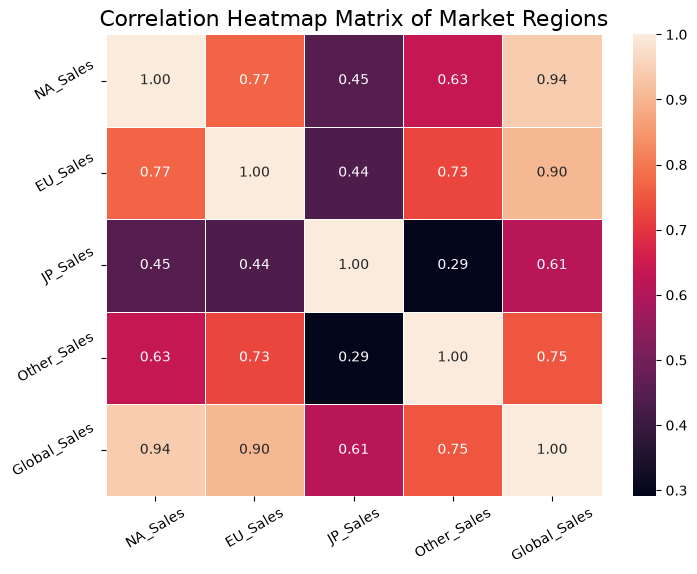

In [78]:
plt.figure(figsize=(8, 6))
numeric_cols = df[['NA_Sales', 'EU_Sales', 'JP_Sales', 'Other_Sales', 'Global_Sales']]  #getting the numeric columns first cuz we need it for correlation
correlation_matrix = numeric_cols.corr()

sns.heatmap(correlation_matrix, annot=True, cmap='rocket', fmt='.2f', linewidths=0.5)
plt.title('Correlation Heatmap Matrix of Market Regions', fontsize = 16)
plt.yticks(rotation=30)
plt.xticks(rotation=30)

plt.show()

**Interpretation:** This heatmap shows how closely game sales in different regions are related. The strongest relationship is between North America and Europe, with a correlation of 0.77, which means games that sell well in North America usually do well in Europe too. Japan has a weaker correlation with the other regions, suggesting that game preferences there are often different from those in Western markets.

### And thats it! -w-